1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

2. Load Dataset

In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3. Understand the Target

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

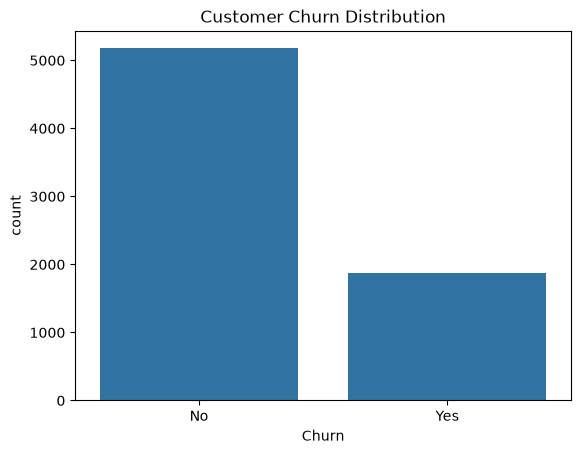

In [5]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

4. Numerical Features

In [7]:
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

5. Distribution of Numerical Features

In [8]:
numerical_columns = [
    "tenure",
    "MonthlyCharges"
]

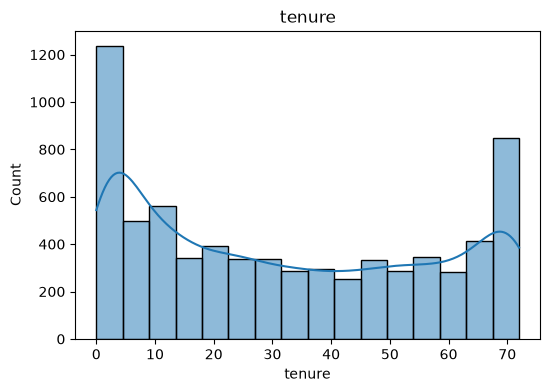

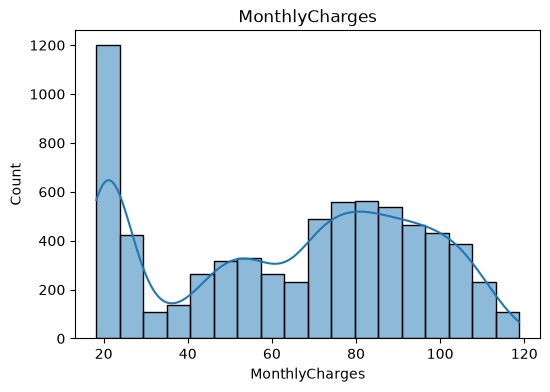

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

#### Why `SeniorCitizen` is not included?

Although `SeniorCitizen` has a numeric data type (`0` and `1`), it represents **categories**, not continuous numerical values.

- **0** → Not a Senior Citizen
- **1** → Senior Citizen

That's why:

- `tenure` and `MonthlyCharges` → **Continuous numerical features** → Use `histplot()`
- `SeniorCitizen` → **Categorical feature (binary)** → Use `countplot()`
- `TotalCharges` is often loaded as an object because of blank values.

6. Boxplots

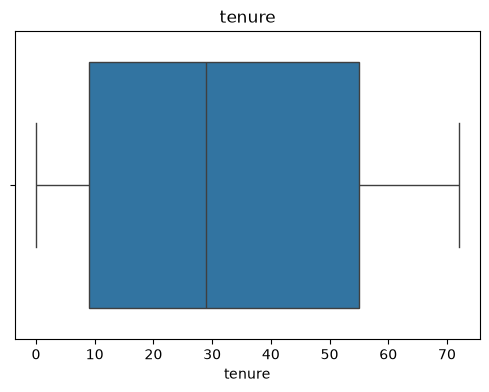

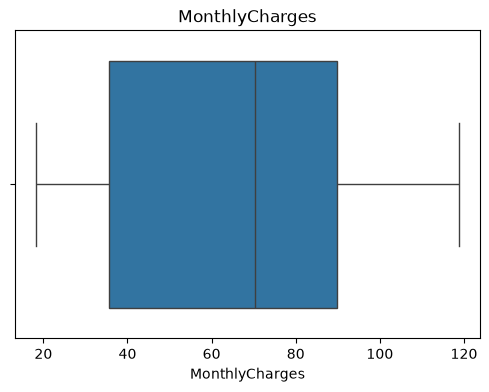

In [13]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

- No Outlier Present

7. Churn vs Numerical Features

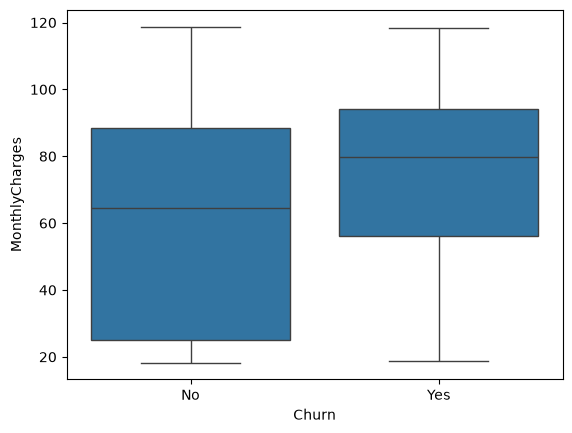

In [15]:
sns.boxplot(
    data = df,
    x="Churn",
    y="MonthlyCharges"
)
plt.show()

#### Monthly Charges vs Churn

- Customers who churned generally have higher monthly charges than those who stayed.
- The median monthly charge is noticeably higher for churned customers.
- This suggests that higher monthly charges may be associated with a higher likelihood of churn.

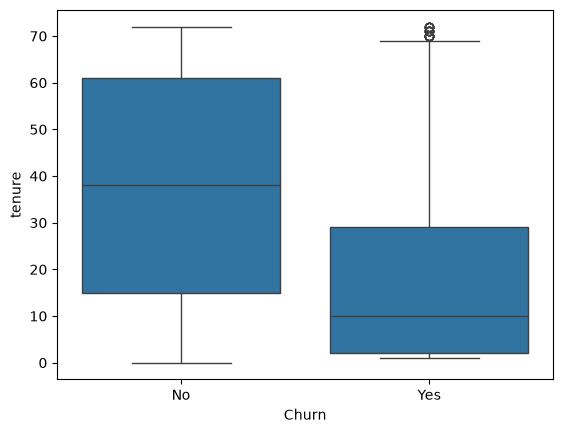

In [16]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.show()

#### Tenure vs Churn

- Customers who churned generally have much shorter tenure than those who stayed.
- The median tenure of churned customers is significantly lower.
- This indicates that newer customers are more likely to churn, while long-term customers tend to remain with the company.

8. Categorical Features

In [23]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
categorical_columns.remove("customerID")

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_29808/3085925487.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [24]:
print(categorical_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


9. Count Plots

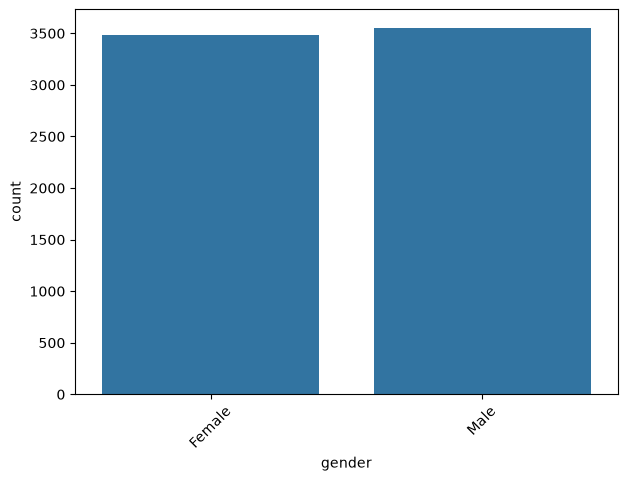

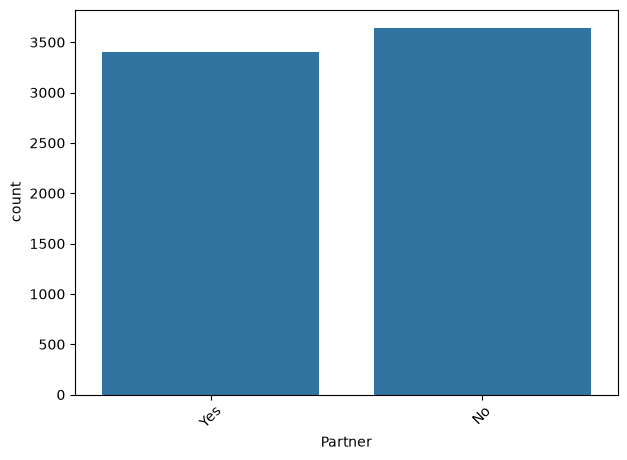

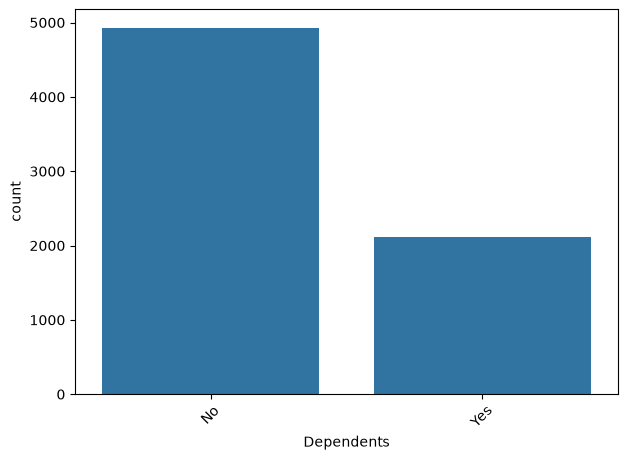

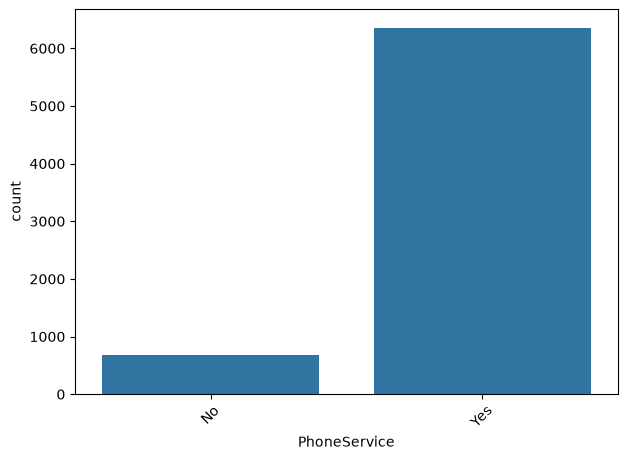

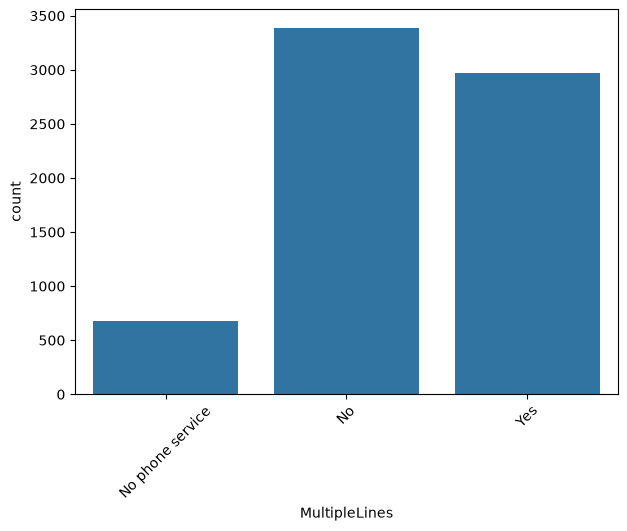

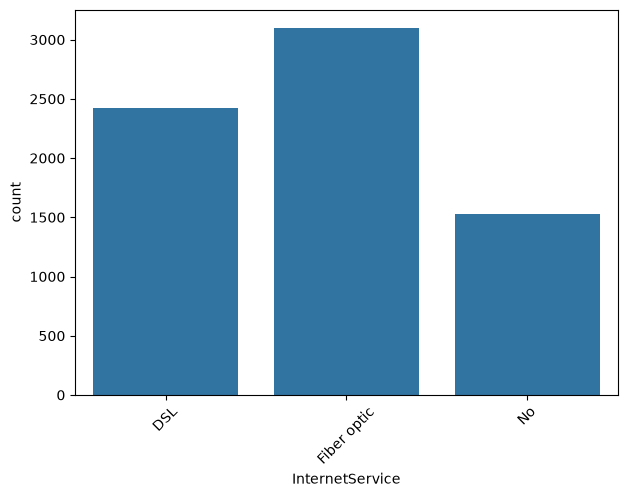

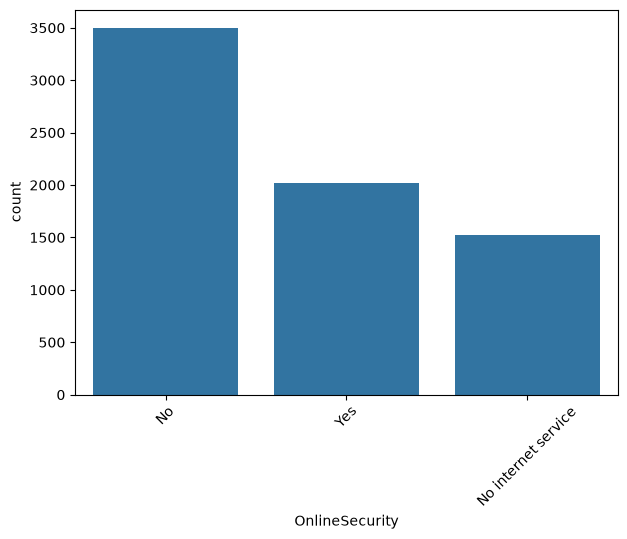

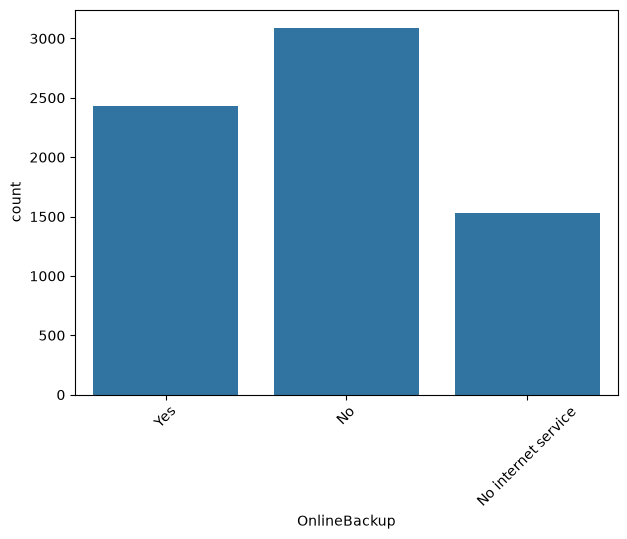

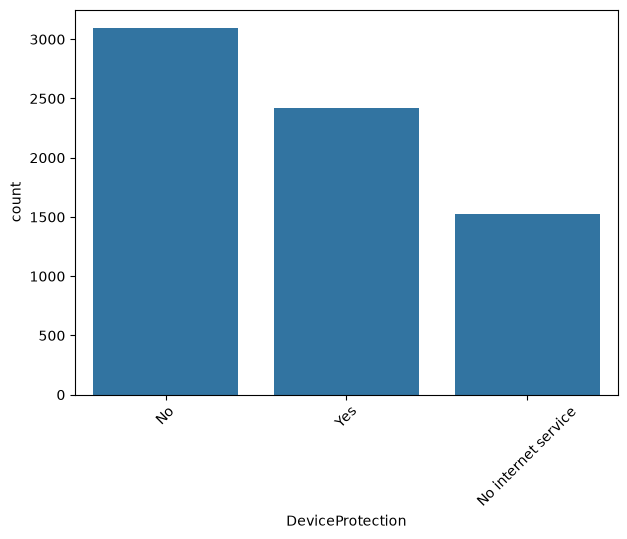

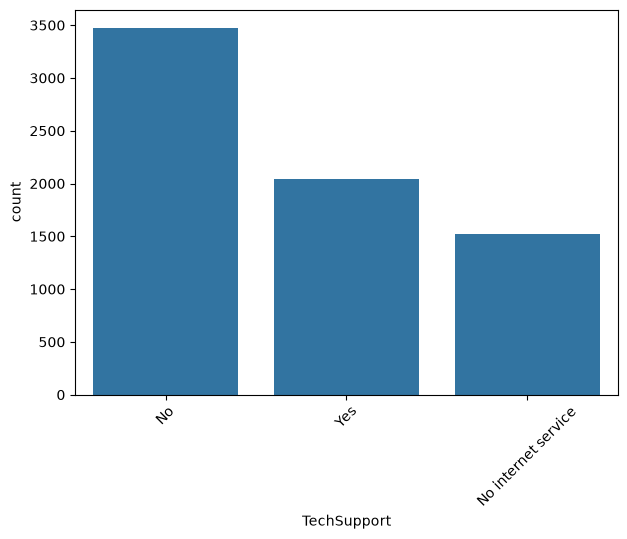

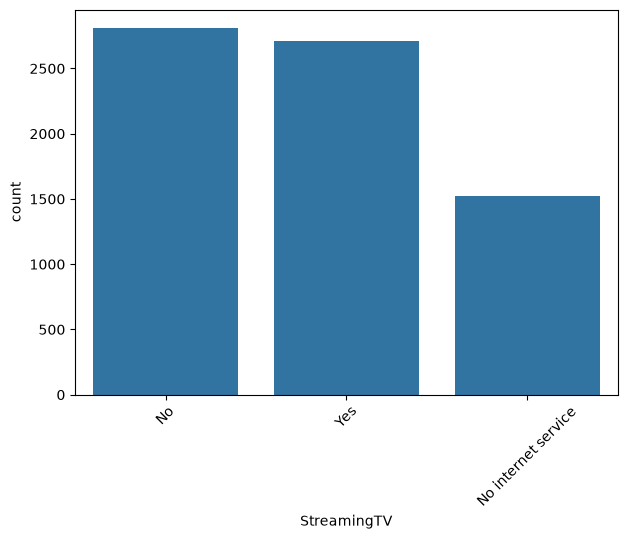

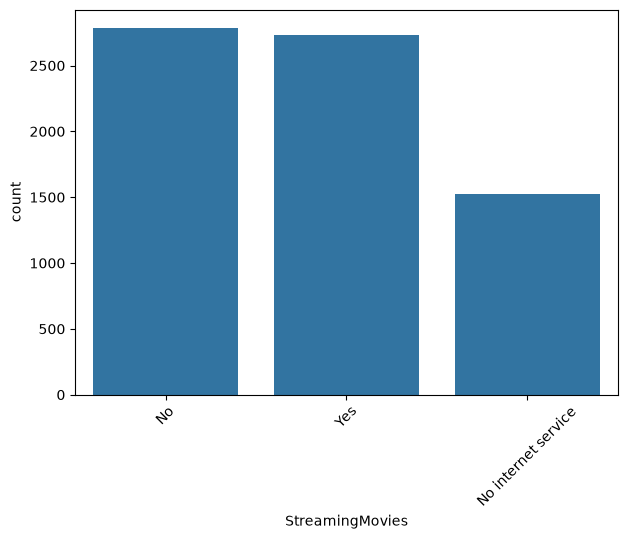

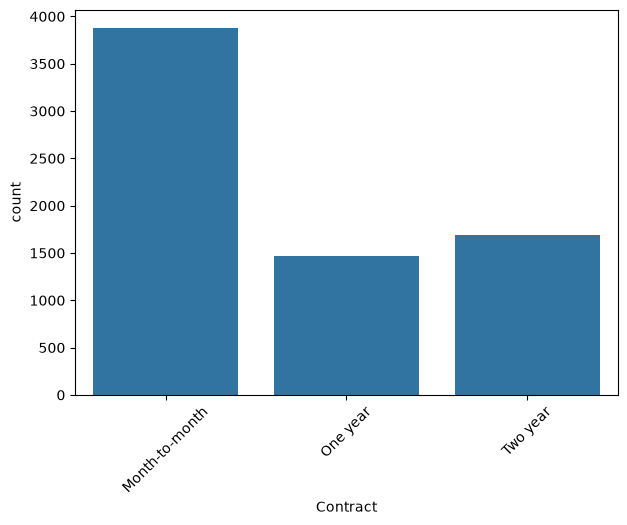

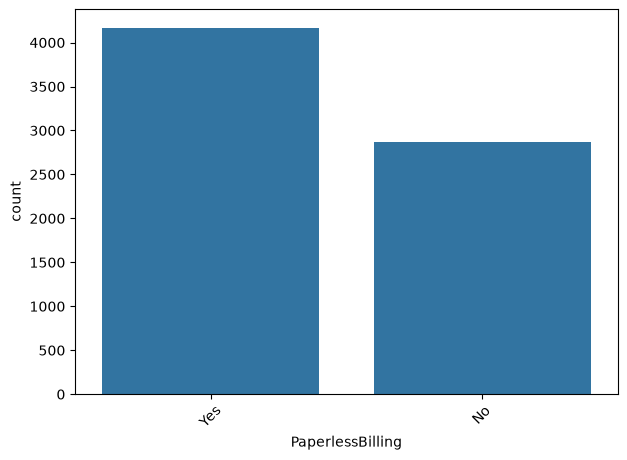

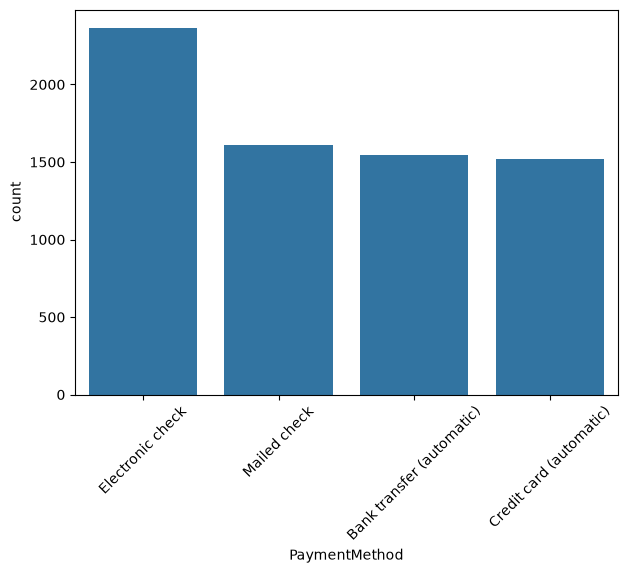

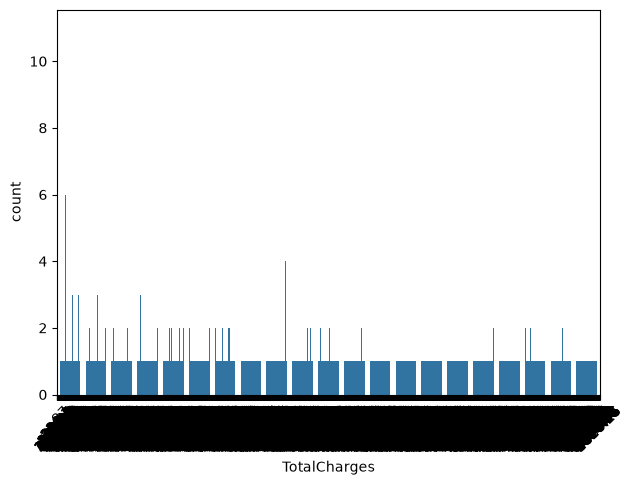

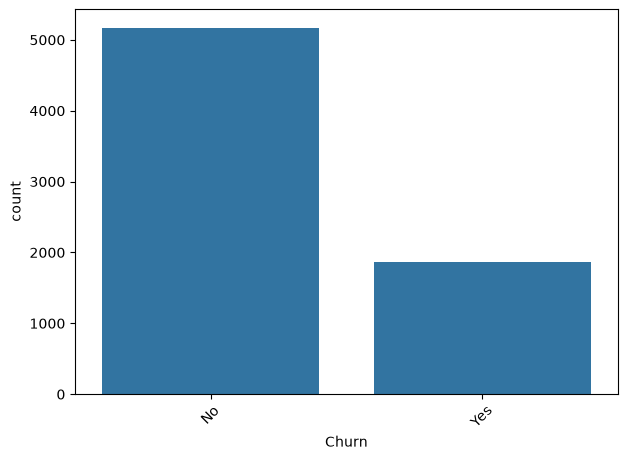

In [28]:
for col in categorical_columns:
    plt.figure(figsize=(7,5))
    sns.countplot(
        data=df,
        x=col
    )
    plt.xticks(rotation=45)
    plt.show()

10. Churn vs Categorical Features

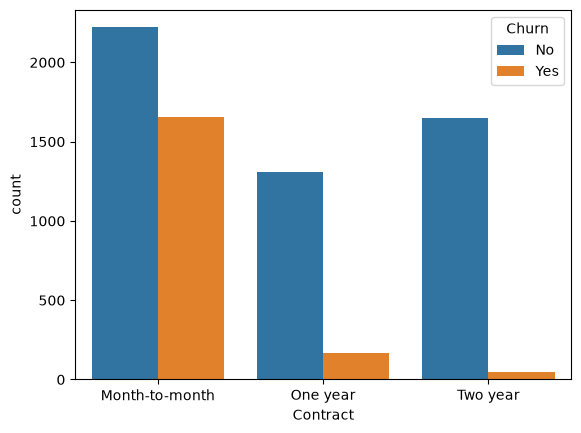

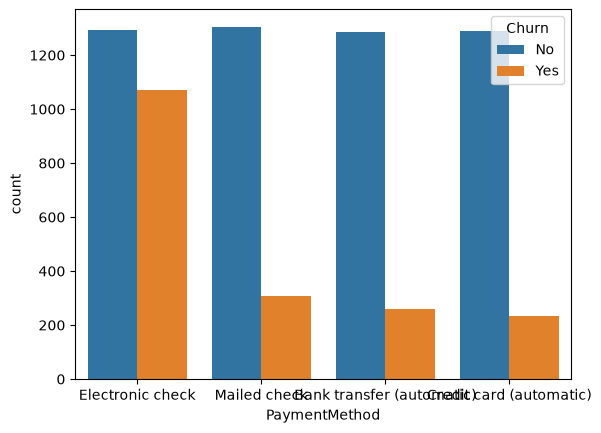

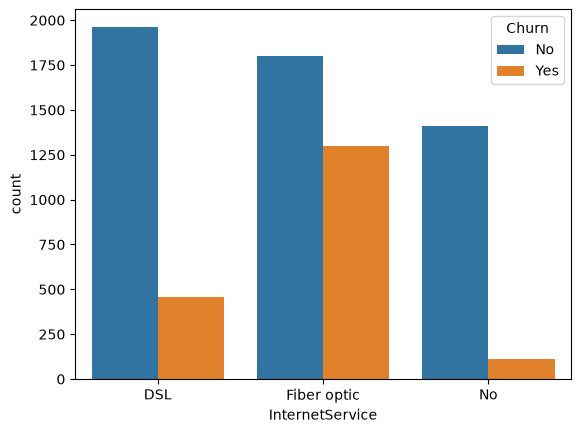

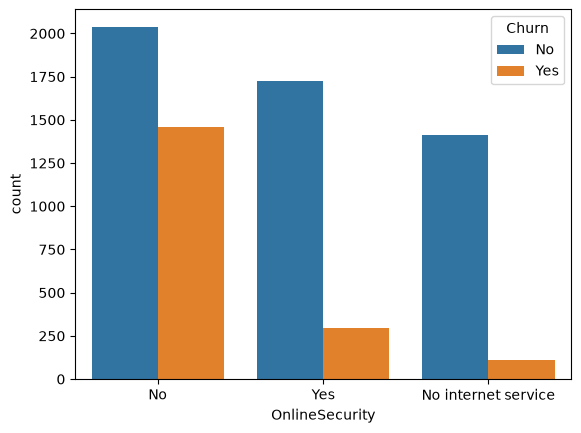

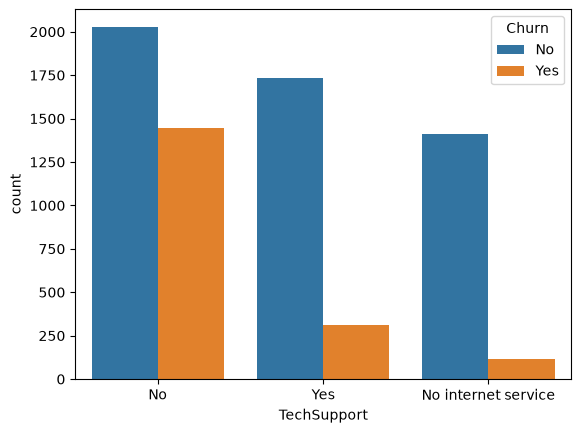

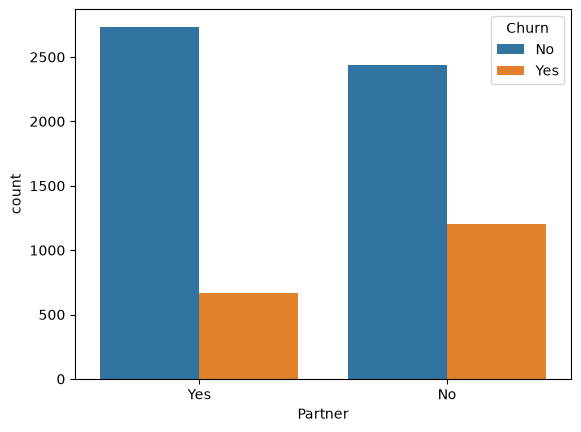

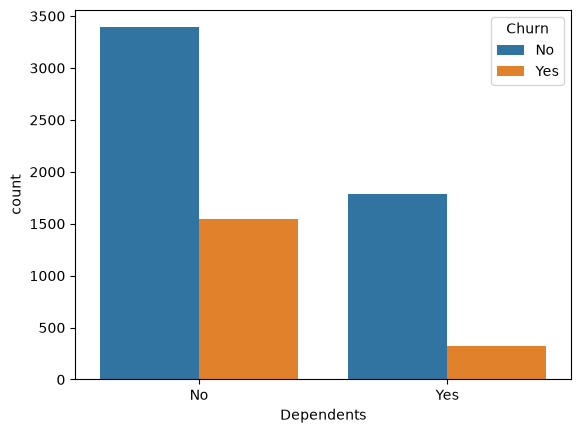

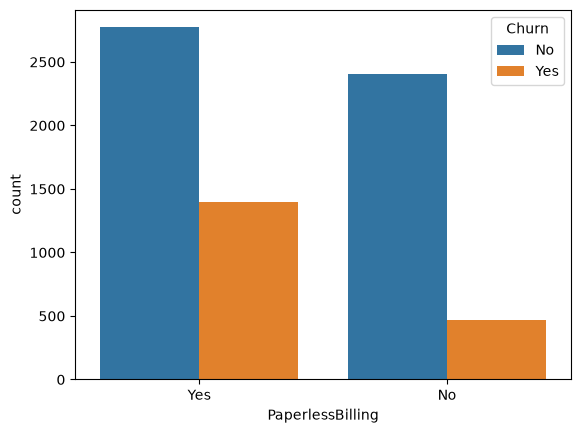

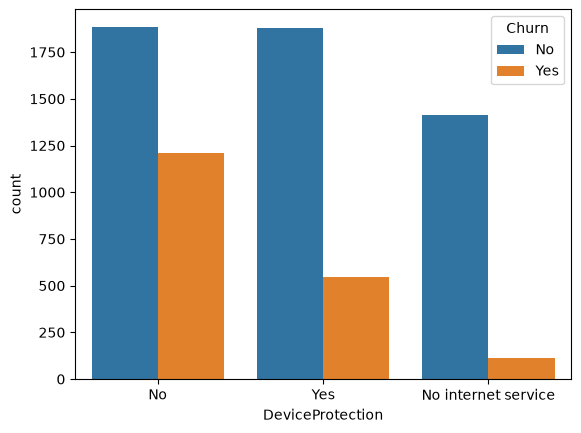

In [32]:
main_categorical_columns = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Partner",
    "Dependents",
    "PaperlessBilling",
    "DeviceProtection"
]

for col in main_categorical_columns:
    sns.countplot(
        data = df,
        x=col,
        hue="Churn"
    )
    plt.show()

### Observation
1. Contract

Customers with month-to-month contracts have the highest churn, while one-year and two-year contracts have significantly lower churn.

2. Payment Method

Customers using Electronic Check show the highest churn compared to other payment methods.

3. Internet Service

Customers with Fiber Optic internet have the highest churn, whereas DSL and No Internet Service customers churn much less.

4. Online Security

Customers without Online Security are much more likely to churn than those who have Online Security.

5. Tech Support

Customers without Tech Support exhibit significantly higher churn than customers who receive Tech Support.

6. Partner

Customers without a partner have a higher churn rate compared to customers who have a partner.

7. Dependents

Customers without dependents are more likely to churn than customers with dependents.

8. Paperless Billing

Customers using Paperless Billing tend to churn more frequently than those who do not use it.

9. Device Protection

Customers without Device Protection have a higher churn rate than customers who have Device Protection.

11. Correlation

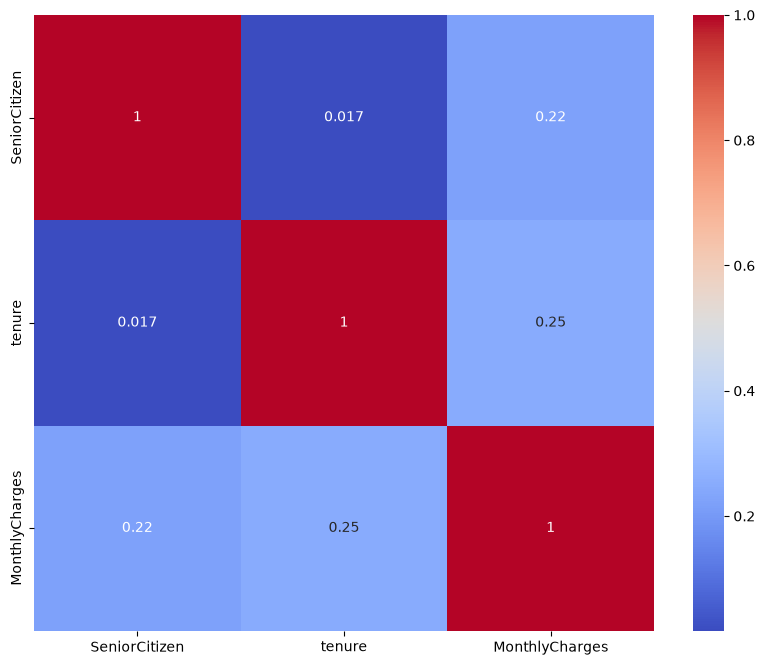

In [34]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot = True,
    cmap = 'coolwarm'
)
plt.show()

### Observation
None of them have a strong correlation with each other.

12. Pairplot

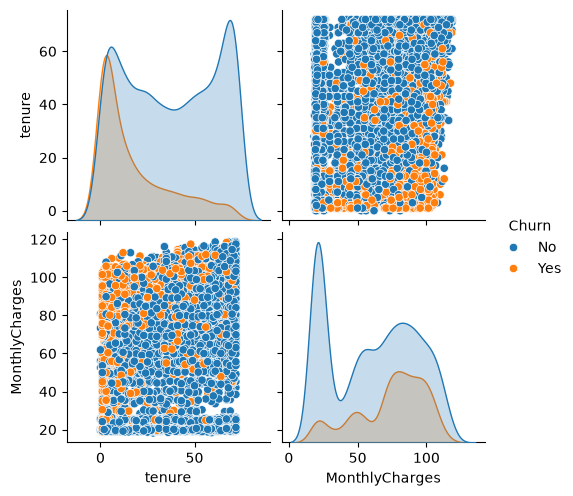

In [35]:
sns.pairplot(
    df[
        [
            "tenure",
            "MonthlyCharges",
            "Churn"
        ]
    ],
    hue="Churn"
)

## Key Learnings

### Objective
Performed exploratory data analysis (EDA) on the Telco Customer Churn dataset to understand customer behavior, identify relationships between features and churn, detect data quality issues, and determine the preprocessing steps required for building an Artificial Neural Network (ANN).

---

## Business Insights

The exploratory analysis provided several valuable business insights:

1. Customers with **month-to-month contracts** exhibit significantly higher churn compared to customers with one-year or two-year contracts.
2. Customers with **shorter tenure** are more likely to leave the company than long-term customers.
3. Higher **Monthly Charges** are associated with a higher probability of customer churn.
4. Customers who **do not subscribe to Online Security or Tech Support services** tend to churn more frequently.
5. Customers using **Fiber Optic Internet Service** show a higher churn rate compared to DSL users.
6. Customers using **Electronic Check** as their payment method appear to churn more often than customers using automatic payment methods.
7. Long-term customers generally demonstrate higher retention and customer loyalty.

---

### Deep Learning Perspective

Based on the exploratory data analysis, the following preprocessing steps and ANN design decisions were identified:

### Required Preprocessing

- Remove unnecessary identifier columns such as `customerID`.
- Handle missing or invalid values in the `TotalCharges` column.
- Apply Label Encoding for binary categorical variables.
- Apply One-Hot Encoding for multi-category features.
- Perform Feature Scaling using StandardScaler before training the ANN.

### Why Feature Scaling?

Artificial Neural Networks are optimized using Gradient Descent. Since gradient-based optimization is sensitive to the scale of input features, feature scaling helps:

- Prevent features with larger magnitudes from dominating learning.
- Improve model stability and overall performance.

### Planned ANN Configuration

| Component | Selected Choice |
|------------|----------------|
| Problem Type | Binary Classification |
| Output Layer | 1 Neuron |
| Output Activation | Sigmoid |
| Loss Function | Binary Crossentropy |
| Optimizer | Adam |
| Evaluation Metrics | Accuracy, Precision, Recall, F1 Score, ROC-AUC |

These choices align with the binary classification nature of the customer churn prediction problem.

---

### Key Learnings

- Exploratory Data Analysis provides valuable insights into customer behavior before model development.
- Understanding feature distributions helps identify appropriate preprocessing techniques.
- Feature scaling and categorical encoding are essential for effective ANN training.
- Business insights obtained through EDA can guide both feature engineering and organizational decision-making.
- Proper understanding of the dataset enables the design of a more efficient and reliable deep learning model.

---

### Outcome

Successfully completed Exploratory Data Analysis and developed a comprehensive understanding of:

- Customer churn behavior.
- Relationships between customer attributes and churn.
- Numerical and categorical feature distributions.
- Potential preprocessing requirements.
- Business insights for customer retention.
- Deep learning model design decisions.

The dataset is now well understood and ready for the Data Preprocessing phase, where missing values, feature encoding, and feature scaling will be implemented before training the Artificial Neural Network.